In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
data = pd.read_excel("Week 2 (DataSet).xlsx")
print(data.head())

                  date  Usage_kWh  Lagging_Current_Reactive.Power_kVarh  \
0  2018-01-01 00:15:00       3.17                                  2.95   
1  2018-01-01 00:30:00       4.00                                  4.46   
2  2018-01-01 00:45:00       3.24                                  3.28   
3  2018-01-01 01:00:00       3.31                                  3.56   
4  2018-01-01 01:15:00       3.82                                  4.50   

   Leading_Current_Reactive_Power_kVarh  CO2(tCO2)  \
0                                   0.0        0.0   
1                                   0.0        0.0   
2                                   0.0        0.0   
3                                   0.0        0.0   
4                                   0.0        0.0   

   Lagging_Current_Power_Factor  Leading_Current_Power_Factor   NSM  \
0                         73.21                         100.0   900   
1                         66.77                         100.0  1800   
2          

In [4]:
print(data.shape)
print(data.columns)
print(data.info())

(35040, 11)
Index(['date', 'Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)',
       'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM',
       'WeekStatus', 'Day_of_week', 'Load_Type'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  object 
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float6

In [6]:
X = data.drop(["Usage_kWh", "date"], axis=1)
y = data["Usage_kWh"]

In [7]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
X["WeekStatus"] = encoder.fit_transform(X["WeekStatus"])
X["Day_of_week"] = encoder.fit_transform(X["Day_of_week"])
X["Load_Type"] = encoder.fit_transform(X["Load_Type"])

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
scaler.fit_transform(X_train)

array([[-0.79850885,  2.4044573 , -0.71176756, ...,  1.58212649,
        -0.49536067,  1.44571194],
       [-0.49551538, -0.52245816, -0.71176756, ..., -0.63206072,
         1.50254594, -0.8851883 ],
       [-0.34739889, -0.52245816, -0.71176756, ..., -0.63206072,
        -1.49431398, -0.8851883 ],
       ...,
       [-0.78990457,  1.40328557, -0.0907626 , ...,  1.58212649,
        -0.49536067,  0.28026182],
       [-0.53300544, -0.52245816, -0.71176756, ..., -0.63206072,
         1.00306928, -0.8851883 ],
       [-0.79850885,  2.17197044, -0.71176756, ..., -0.63206072,
         0.50359263,  1.44571194]], shape=(28032, 9))

In [14]:
from sklearn.decomposition import PCA
pca = PCA(n_components=X_train_scaled.shape[1])
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
print("Original Training Shape :", X_train_scaled.shape)
print("PCA Training Shape      :", X_train_pca.shape)
print("Original Testing Shape  :", X_test_scaled.shape)
print("PCA Testing Shape       :", X_test_pca.shape)
print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)
import numpy as np
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
print("\nCumulative Explained Variance:")
print(cumulative_variance)

Original Training Shape : (28032, 9)
PCA Training Shape      : (28032, 9)
Original Testing Shape  : (7008, 9)
PCA Testing Shape       : (7008, 9)

Explained Variance Ratio:
[0.33677358 0.30462665 0.1176958  0.08789181 0.06838273 0.0419787
 0.03074086 0.007047   0.00486287]

Cumulative Explained Variance:
[0.33677358 0.64140023 0.75909603 0.84698784 0.91537057 0.95734926
 0.98809013 0.99513713 1.        ]


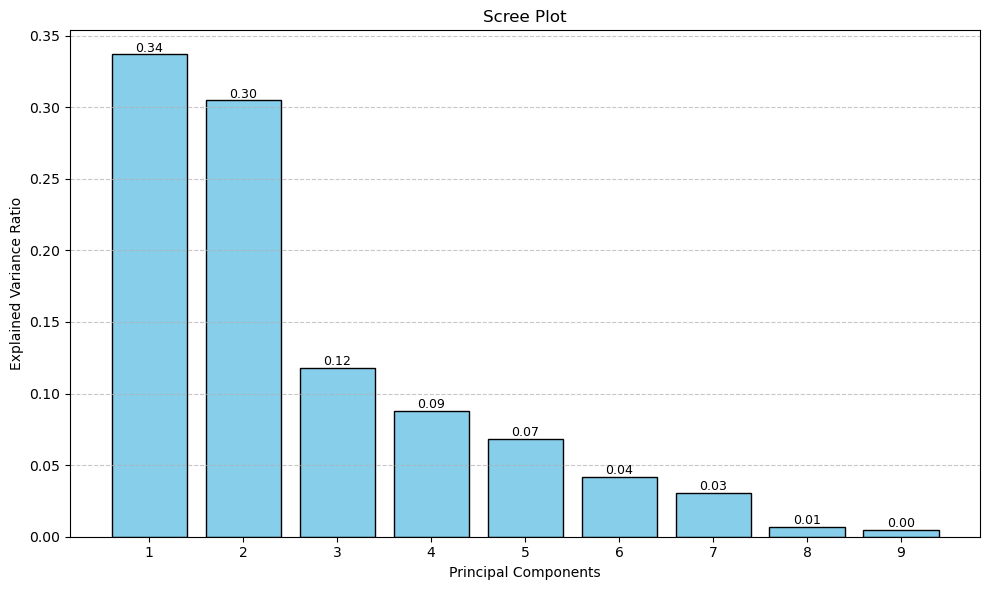

In [15]:
import matplotlib.pyplot as plt
import numpy as np
explained_variance = pca.explained_variance_ratio_
plt.figure(figsize=(10,6))
plt.bar(
    range(1, len(explained_variance) + 1),
    explained_variance,
    color='skyblue',
    edgecolor='black'
)
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.xticks(range(1, len(explained_variance) + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
for i, value in enumerate(explained_variance):
    plt.text(i + 1, value + 0.002, f"{value:.2f}", ha='center', fontsize=9)
plt.tight_layout()
plt.show()

Number of components required to retain 95% variance: 6


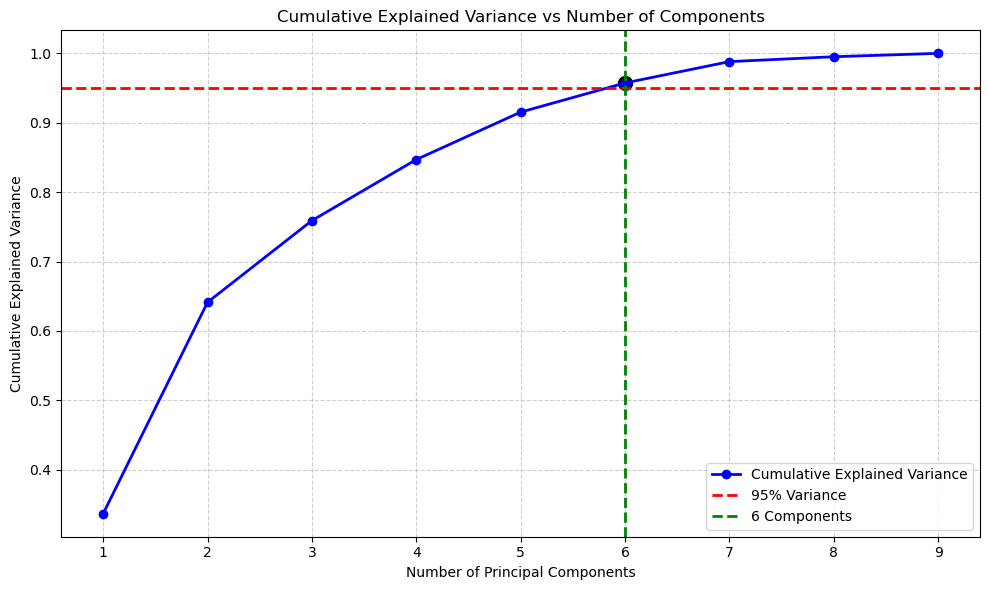

In [16]:
import numpy as np
import matplotlib.pyplot as plt
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Number of components required to retain 95% variance: {n_components_95}")
plt.figure(figsize=(10,6))
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker='o',
    linewidth=2,
    color='blue',
    label='Cumulative Explained Variance'
)
plt.axhline(
    y=0.95,
    color='red',
    linestyle='--',
    linewidth=2,
    label='95% Variance'
)
plt.axvline(
    x=n_components_95,
    color='green',
    linestyle='--',
    linewidth=2,
    label=f'{n_components_95} Components'
)
plt.scatter(
    n_components_95,
    cumulative_variance[n_components_95 - 1],
    color='black',
    s=100
)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance vs Number of Components")
plt.xticks(range(1, len(cumulative_variance) + 1))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd
pca_3 = PCA(n_components=3)
X_train_pca3 = pca_3.fit_transform(X_train_scaled)
X_test_pca3 = pca_3.transform(X_test_scaled)
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )
}
results = []
for name, model in models.items():
    model.fit(X_train_pca3, y_train)
    y_pred = model.predict(X_test_pca3)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results.append([name, rmse, r2])
results_df = pd.DataFrame(
    results,
    columns=["Model", "RMSE", "R2 Score"]
)
print(results_df)

               Model       RMSE  R2 Score
0  Linear Regression  10.810872  0.897183
1      Decision Tree   6.025940  0.968056
2      Random Forest   4.667700  0.980833


In [19]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd
pca_95 = PCA(n_components=n_components_95)
X_train_pca95 = pca_95.fit_transform(X_train_scaled)
X_test_pca95 = pca_95.transform(X_test_scaled)
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )
}
results_95 = []
for name, model in models.items():
    model.fit(X_train_pca95, y_train)
    y_pred = model.predict(X_test_pca95)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results_95.append([name, rmse, r2])
results_95_df = pd.DataFrame(
    results_95,
    columns=["Model", "RMSE", "R2 Score"]
)
print(results_95_df)

               Model      RMSE  R2 Score
0  Linear Regression  6.194903  0.966239
1      Decision Tree  4.058306  0.985511
2      Random Forest  2.913831  0.992531


In [20]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )
}
comparison_results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred_original = model.predict(X_test_scaled)
    original_rmse = np.sqrt(mean_squared_error(y_test, y_pred_original))
    original_r2 = r2_score(y_test, y_pred_original)
    model.fit(X_train_pca3, y_train)
    y_pred_pca3 = model.predict(X_test_pca3)
    pca3_rmse = np.sqrt(mean_squared_error(y_test, y_pred_pca3))
    pca3_r2 = r2_score(y_test, y_pred_pca3)
    model.fit(X_train_pca95, y_train)
    y_pred_pca95 = model.predict(X_test_pca95)
    pca95_rmse = np.sqrt(mean_squared_error(y_test, y_pred_pca95))
    pca95_r2 = r2_score(y_test, y_pred_pca95)
    comparison_results.append([
        name,
        original_rmse,
        original_r2,
        pca3_rmse,
        pca3_r2,
        pca95_rmse,
        pca95_r2
    ])
comparison_df = pd.DataFrame(
    comparison_results,
    columns=[
        "Model",
        "Original RMSE",
        "Original R2",
        "PCA (3) RMSE",
        "PCA (3) R2",
        "PCA (95%) RMSE",
        "PCA (95%) R2"
    ]
)
print(comparison_df)

               Model  Original RMSE  Original R2  PCA (3) RMSE  PCA (3) R2  \
0  Linear Regression       4.227186     0.984280     10.810872    0.897183   
1      Decision Tree       1.429789     0.998202      6.025940    0.968056   
2      Random Forest       1.055426     0.999020      4.667700    0.980833   

   PCA (95%) RMSE  PCA (95%) R2  
0        6.194903      0.966239  
1        4.058306      0.985511  
2        2.913831      0.992531  


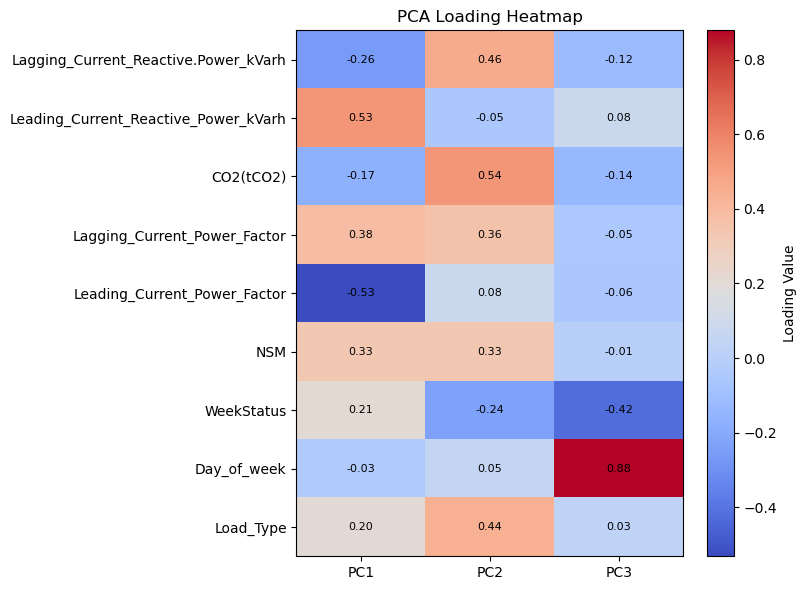


PCA Loadings:
                                           PC1       PC2       PC3
Lagging_Current_Reactive.Power_kVarh -0.256154  0.458952 -0.121611
Leading_Current_Reactive_Power_kVarh  0.534371 -0.054356  0.084523
CO2(tCO2)                            -0.171495  0.535304 -0.139004
Lagging_Current_Power_Factor          0.378526  0.356331 -0.048675
Leading_Current_Power_Factor         -0.531371  0.082371 -0.061908
NSM                                   0.327885  0.332308 -0.007030
WeekStatus                            0.209375 -0.238414 -0.423596
Day_of_week                          -0.033785  0.051674  0.878733
Load_Type                             0.203216  0.442901  0.029800


In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
loadings = pd.DataFrame(
    pca.components_[:3].T,
    columns=['PC1', 'PC2', 'PC3'],
    index=X.columns
)
plt.figure(figsize=(8,6))
plt.imshow(loadings, cmap='coolwarm', aspect='auto')
plt.xticks(
    ticks=np.arange(len(loadings.columns)),
    labels=loadings.columns
)
plt.yticks(
    ticks=np.arange(len(loadings.index)),
    labels=loadings.index
)
plt.colorbar(label='Loading Value')
plt.title("PCA Loading Heatmap")
for i in range(loadings.shape[0]):
    for j in range(loadings.shape[1]):
        plt.text(
            j,
            i,
            f"{loadings.iloc[i, j]:.2f}",
            ha='center',
            va='center',
            color='black',
            fontsize=8
        )

plt.tight_layout()
plt.show()
print("\nPCA Loadings:")
print(loadings)

In [ ]:
# Dimensionality Reduction Report

## Objective

The objective of this experiment was to reduce the dimensionality of the dataset using Principal Component Analysis (PCA) while maintaining model performance. PCA helps reduce the number of input features by transforming them into a smaller set of principal components that preserve most of the original information.

---

## Methodology

The following steps were performed:

1. Loaded the preprocessed dataset from Week 2.
2. Split the dataset into training and testing sets.
3. Applied StandardScaler on the training data.
4. Applied PCA using all features.
5. Generated the Scree Plot and Cumulative Explained Variance Plot.
6. Identified the number of principal components required to retain 95% of the total variance.
7. Trained machine learning models using:
   - Original Features
   - First 3 Principal Components
   - PCA Components retaining 95% variance
8. Compared RMSE and R² scores of all models.

---

## Results

Three different versions of the dataset were compared:

- Original Dataset
- PCA with 3 Components
- PCA with 95% Variance Components

The evaluation metrics used were:

- Root Mean Squared Error (RMSE)
- R² Score

The comparison showed that:

- The Original Model achieved the best prediction performance.
- The PCA model with only 3 components showed a slight decrease in accuracy because a large amount of information was compressed into only three components.
- The PCA model retaining 95% of the variance produced results very close to the original model while using fewer features.

---

## Did Accuracy Drop Significantly?

No.

The model using PCA with 95% explained variance experienced only a small decrease in prediction accuracy compared to the original model.

However, using only three principal components reduced the model accuracy more noticeably because too much information was removed.

---

## How Many Features Can Safely Be Removed?

Based on the cumulative explained variance analysis, only the number of principal components required to retain 95% of the total variance should be kept.

This reduced the dimensionality while preserving almost all of the useful information contained in the original dataset.

Therefore, the remaining low-variance features can safely be removed.

---

## Recommendation

Yes.

PCA is recommended for memory-constrained devices because:

- It reduces the number of input features.
- It decreases memory usage.
- It speeds up model training.
- It reduces prediction time.
- It removes redundant information.
- It helps reduce overfitting.
- It makes the model more efficient while maintaining similar prediction performance.

For applications where computational resources are limited, using PCA with 95% explained variance is a good balance between accuracy and efficiency.

--
## Conclusion
Principal Component Analysis successfully reduced the dimensionality of the dataset.
The model trained using components that retained 95% of the variance achieved performance close to the original model while using fewer input features.
Therefore, PCA is an effective dimensionality reduction technique and is recommended when reducing computational cost is important.